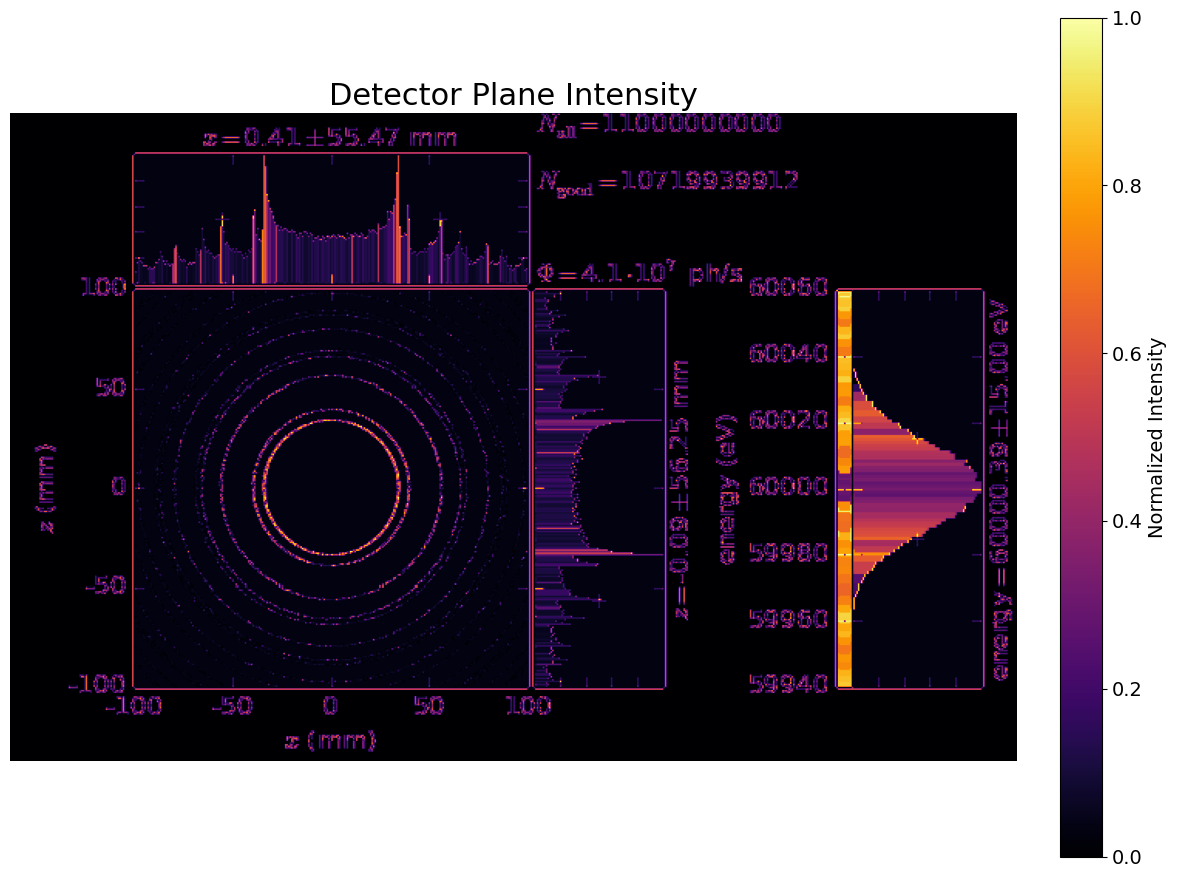

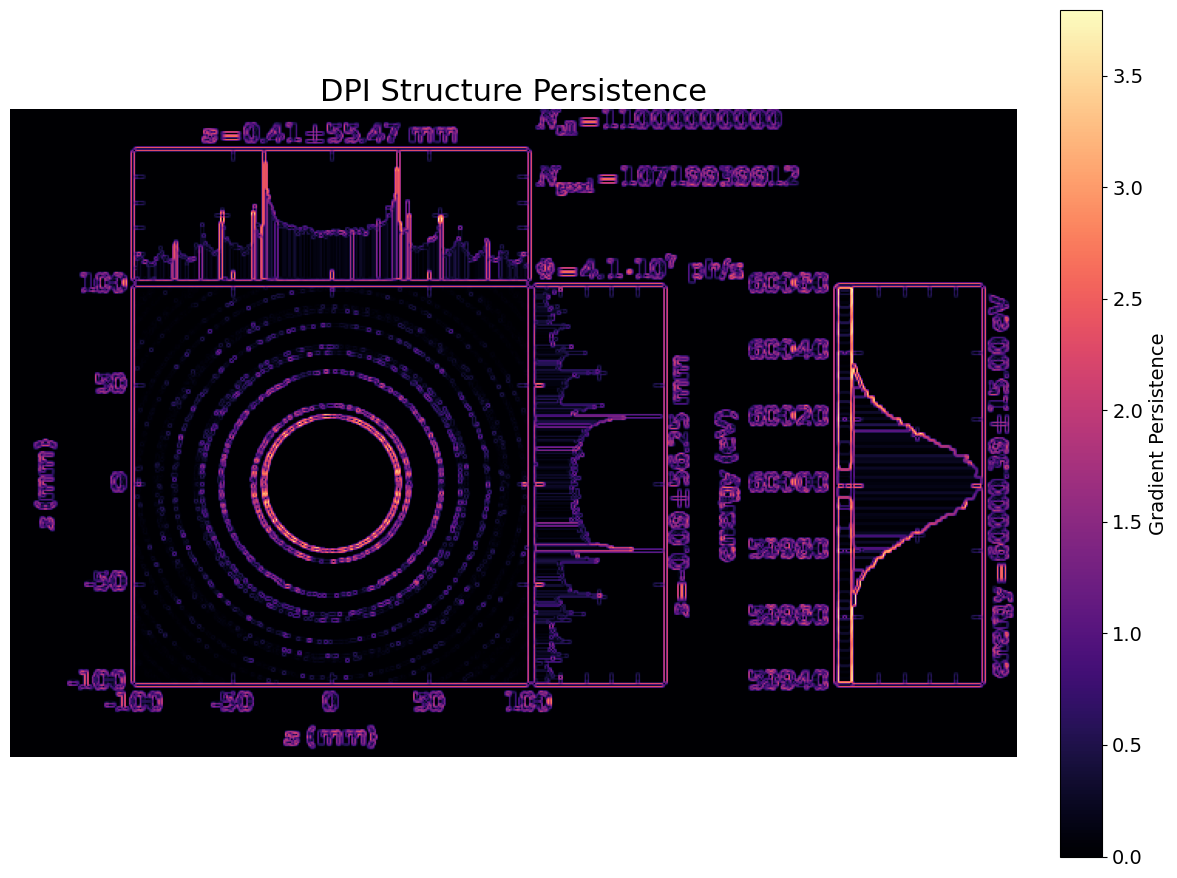

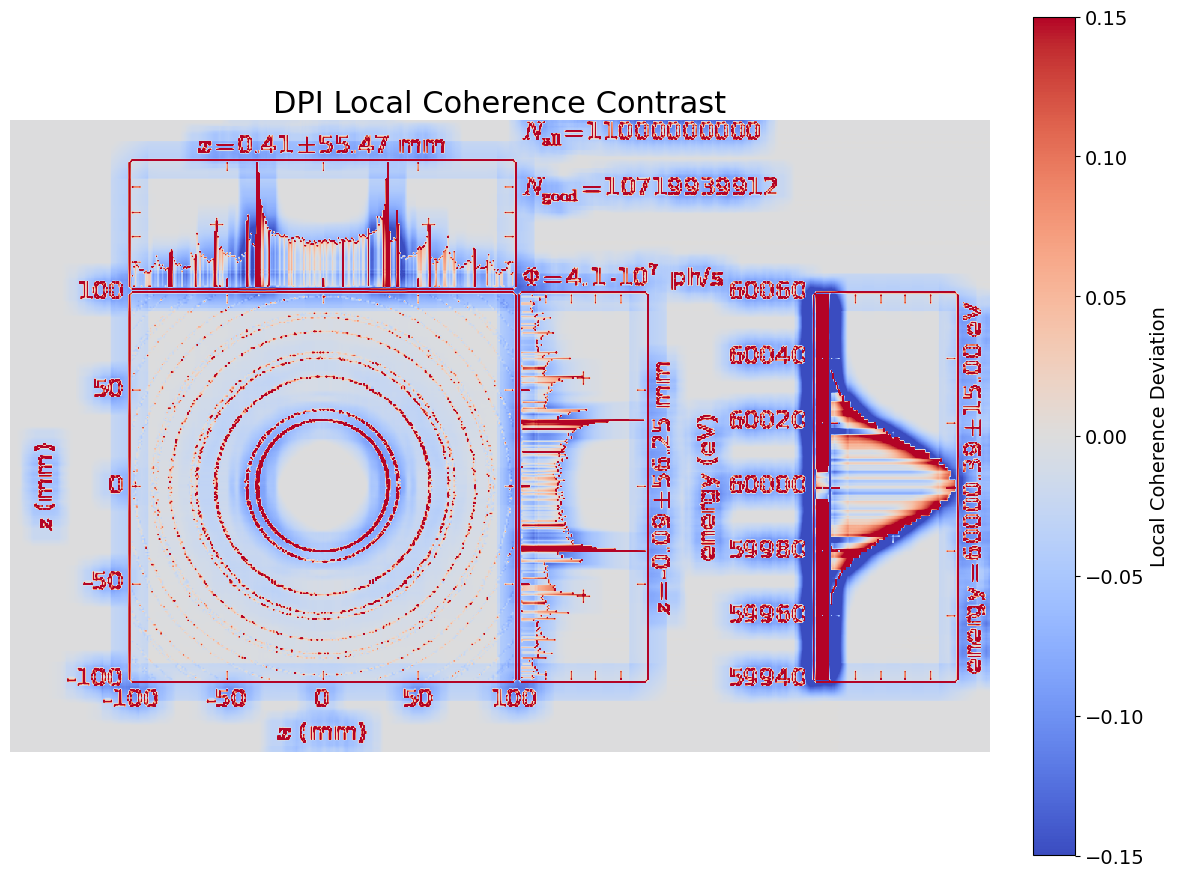

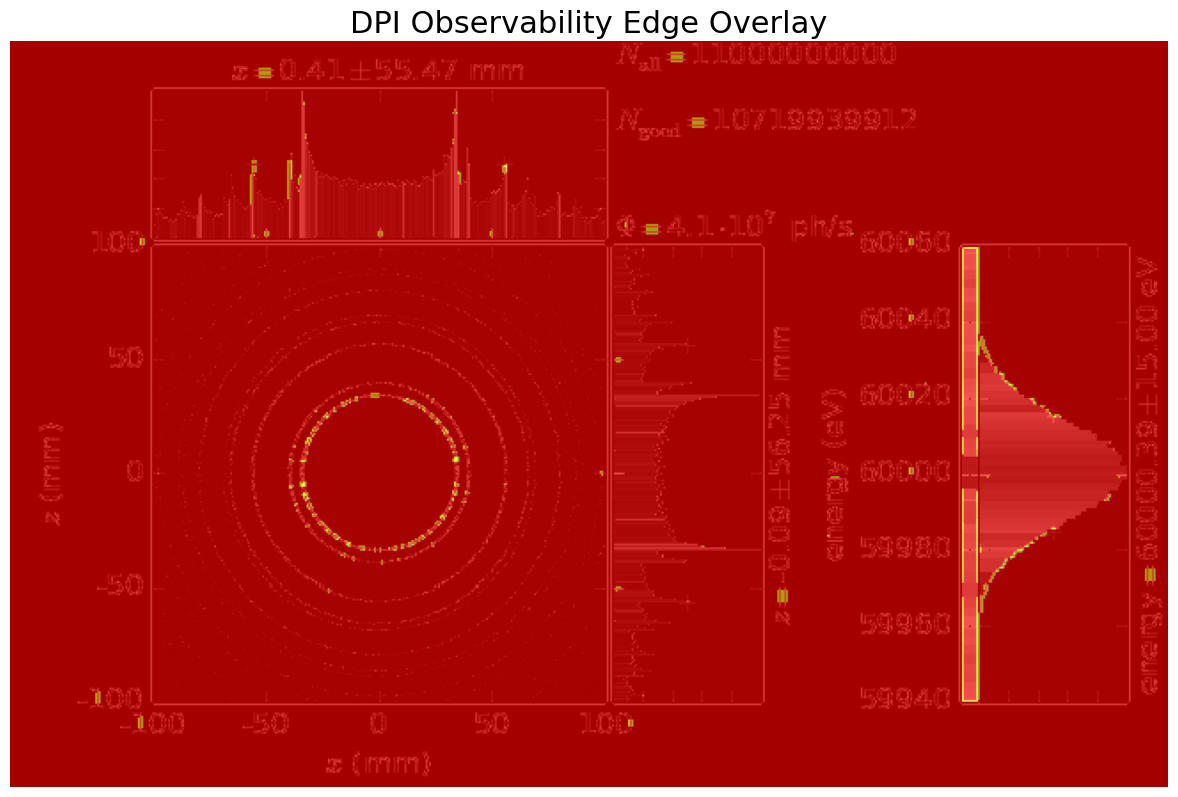

Professional DPI overlays generated successfully.


In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# =========================
# LOAD IMAGE
# =========================

img = Image.open("../outputs/raw/rings_on_detector.png")

gray = np.array(img).astype(float)

# =========================
# NORMALIZE
# =========================

gray_norm = (gray - gray.min()) / (gray.max() - gray.min())

# =========================
# STRUCTURE EXTRACTION
# =========================

sx = ndimage.sobel(gray_norm, axis=0)
sy = ndimage.sobel(gray_norm, axis=1)

sobel = np.hypot(sx, sy)

# =========================
# LOCAL COHERENCE
# =========================

local_mean = ndimage.uniform_filter(gray_norm, size=25)

contrast = gray_norm - local_mean

# =========================
# STRONG EDGE ISOLATION
# =========================

threshold = np.percentile(sobel, 99.5)

edges = sobel > threshold

# =========================
# FIGURE STYLE
# =========================

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 22,
    "axes.labelsize": 14
})

# =====================================================
# 1. DETECTOR PLANE INTENSITY
# =====================================================

fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(gray_norm, cmap="inferno")

ax.set_title("Detector Plane Intensity")

ax.axis("off")

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Normalized Intensity")

plt.tight_layout()

plt.savefig(
    "../outputs/overlays/dpi_intensity_pro.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# =====================================================
# 2. DPI STRUCTURE PERSISTENCE
# =====================================================

fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(sobel, cmap="magma")

ax.set_title("DPI Structure Persistence")

ax.axis("off")

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Gradient Persistence")

plt.tight_layout()

plt.savefig(
    "../outputs/overlays/dpi_structure_pro.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# =====================================================
# 3. LOCAL COHERENCE CONTRAST
# =====================================================

fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(
    contrast,
    cmap="coolwarm",
    vmin=-0.15,
    vmax=0.15
)

ax.set_title("DPI Local Coherence Contrast")

ax.axis("off")

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Local Coherence Deviation")

plt.tight_layout()

plt.savefig(
    "../outputs/overlays/dpi_coherence_pro.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# =====================================================
# 4. CLEAN OBSERVABILITY OVERLAY
# =====================================================

fig, ax = plt.subplots(figsize=(12, 9))

ax.imshow(gray_norm, cmap="gray")

ax.imshow(
    edges,
    cmap="autumn",
    alpha=0.65
)

ax.set_title("DPI Observability Edge Overlay")

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../outputs/overlays/dpi_edges_pro.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Professional DPI overlays generated successfully.")